# 第四部分：描述性统计与可视化

这个 Notebook 使用清洗后的数据做描述统计、画图和 CAPM 回归。运行完成后，主要结果会保存在 `output` 目录，也可以导出为 `report.html`。


In [1]:

from pathlib import Path
import os
import warnings
warnings.filterwarnings('ignore')

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name != 'dshw-p01':
    PROJECT_ROOT = PROJECT_ROOT / 'dshw-p01'
os.makedirs(PROJECT_ROOT, exist_ok=True)

for path in [
    'data/stock', 'data/index', 'data/macro', 'data/finance',
    'data/clean', 'data/combined', 'output'
]:
    os.makedirs(PROJECT_ROOT / path, exist_ok=True)

PROJECT_ROOT


PosixPath('/Users/wonderlab/Desktop/欣欣作业/ds2026/dshw-p01')

## 数据来源与清洗说明（报告导读）

本报告使用 `02_clean.ipynb` 输出的 CSV 文件作为主要数据源，包括 `stock_clean.csv`、`index_clean.csv`、`finance_wide.csv` 和 `combined_data.csv`。股票样本为 10 只 A 股，覆盖汽车、房地产、白酒、能源和通讯 5 个行业；市场基准为沪深 300，宏观变量使用 CPI 同比和 M2 同比。

清洗阶段完成了缺失值检测与处理、日期格式统一、数值字段类型转换、重复交易日删除和离群收益率标注。宏观数据是月度频率，已经按月份映射到股票日度交易数据上；合并时使用左连接，以保留个股交易日样本。


In [2]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats

from matplotlib import font_manager as fm

FONT_CANDIDATES = [
    '/Library/Fonts/Arial Unicode.ttf',
    '/System/Library/Fonts/Supplemental/Arial Unicode.ttf',
    '/System/Library/Fonts/PingFang.ttc',
    '/System/Library/Fonts/Supplemental/Songti.ttc',
    '/System/Library/Fonts/STHeiti Medium.ttc',
]
for font_path in FONT_CANDIDATES:
    if Path(font_path).exists():
        fm.fontManager.addfont(font_path)
        plt.rcParams['font.family'] = fm.FontProperties(fname=font_path).get_name()
        break
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style='whitegrid', font=plt.rcParams.get('font.family', ['sans-serif'])[0])

stock = pd.read_csv(PROJECT_ROOT / 'data/clean/stock_clean.csv', dtype={'code': str}, parse_dates=['date'])
combined = pd.read_csv(PROJECT_ROOT / 'data/combined/combined_data.csv', dtype={'code': str}, parse_dates=['date'])
finance = pd.read_csv(PROJECT_ROOT / 'data/clean/finance_wide.csv', dtype={'code': str})
index = pd.read_csv(PROJECT_ROOT / 'data/clean/index_clean.csv', dtype={'code': str}, parse_dates=['date'])
stock_info = stock[['code', 'name', 'industry']].drop_duplicates().sort_values(['industry', 'code'])
industry_palette = dict(zip(stock_info['industry'].unique(), sns.color_palette('tab10', stock_info['industry'].nunique())))


## 4.1 基本统计量

这里计算 10 只股票日对数收益率的年化均值、年化波动率、偏度、峰度和最大回撤。年化时按一年 252 个交易日处理。


In [3]:

def max_drawdown(close):
    wealth = close / close.iloc[0]
    drawdown = wealth / wealth.cummax() - 1
    return drawdown.min()

stats_rows = []
for code, g in stock.dropna(subset=['return']).groupby('code'):
    g = g.sort_values('date')
    info = g[['name', 'industry']].iloc[0]
    r = g['return'].dropna()
    stats_rows.append({
        '股票': info['name'], '代码': code, '行业': info['industry'],
        '年化均值': r.mean() * 252,
        '年化波动率': r.std() * np.sqrt(252),
        '偏度': r.skew(), '峰度': r.kurt(),
        '最大回撤': max_drawdown(g['close'])
    })
stats_table = pd.DataFrame(stats_rows).sort_values(['行业', '代码'])
stats_table.to_csv(PROJECT_ROOT / 'output/return_summary.csv', index=False, encoding='utf-8-sig')
stats_table


,股票,代码,行业,年化均值,年化波动率,偏度,峰度,最大回撤
1,我爱我家,000560,房地产,-0.056079,0.482649,0.488135,2.231728,-0.721294
5,万通发展,600246,房地产,0.145567,0.573895,0.045906,1.215373,-0.651939
2,长安汽车,000625,汽车,0.080541,0.476472,0.332101,2.223801,-0.599559
9,赛力斯,601127,汽车,0.327108,0.616870,0.358018,0.857615,-0.717122
3,酒鬼酒,000799,白酒,0.033825,0.486968,0.364249,1.915261,-0.867845
6,贵州茅台,600519,白酒,0.050527,0.276169,0.258627,3.624637,-0.474822
7,京能电力,600578,能源,0.160168,0.327879,0.559131,5.100246,-0.386097
8,节能风电,601016,能源,0.160463,0.405930,0.455396,4.630076,-0.605758
0,中兴通讯,000063,通讯,0.018865,0.425718,0.309410,2.445436,-0.618668
4,信维通信,300136,通讯,0.127269,0.530319,0.259667,5.473152,-0.786415


描述统计先给出一个粗略判断：哪些股票收益更高、波动更大，哪些股票的尾部风险更明显。年化波动率和最大回撤主要看风险，偏度和峰度用来观察收益分布是否偏离正态。


## 4.2 可视化

下方依次给出图 1 至图 5，每图配文字解读。

### 图 1：归一化收盘价走势图

把每只股票和沪深 300 在样本期第一个可得收盘价都设为 1，再比较它们后面的相对表现。


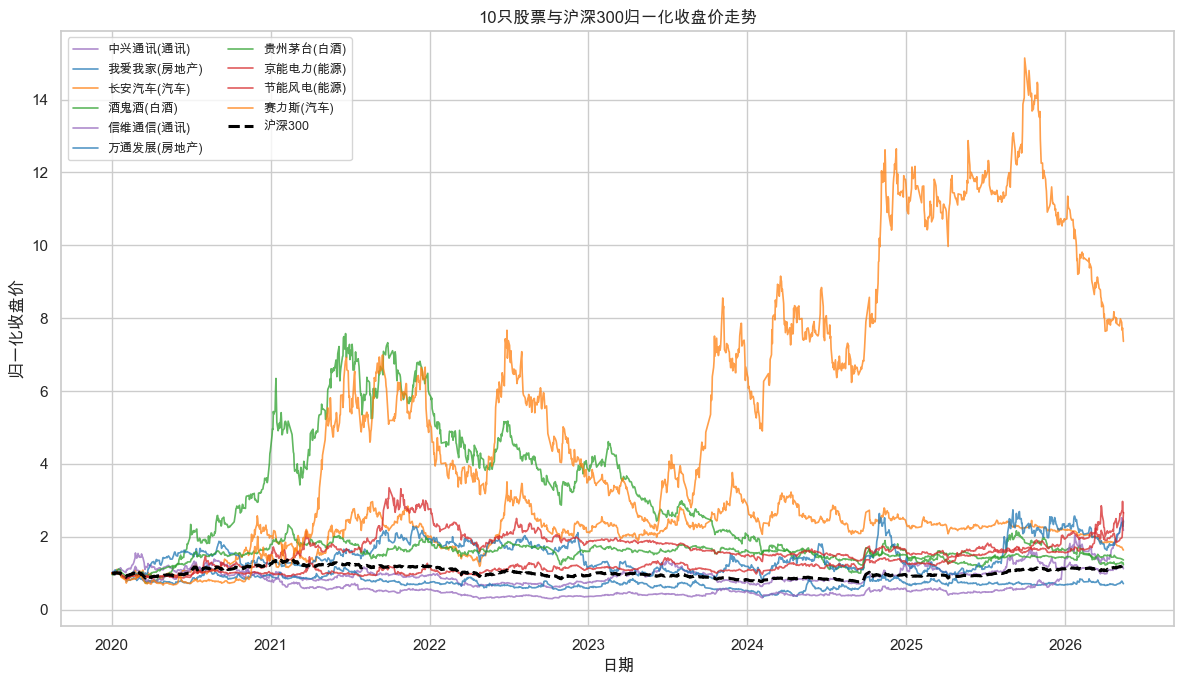

In [4]:

norm_stock = stock.sort_values('date').copy()
norm_stock['norm_close'] = norm_stock.groupby('code')['close'].transform(lambda s: s / s.dropna().iloc[0])
hs300 = index[index['code'] == '000300'].sort_values('date').copy()
hs300['norm_close'] = hs300['close'] / hs300['close'].dropna().iloc[0]

fig, ax = plt.subplots(figsize=(12, 7))
for (code, name, industry), g in norm_stock.groupby(['code', 'name', 'industry']):
    ax.plot(g['date'], g['norm_close'], label=f'{name}({industry})', color=industry_palette[industry], alpha=0.75, linewidth=1.2)
ax.plot(hs300['date'], hs300['norm_close'], label='沪深300', color='black', linewidth=2.2, linestyle='--')
ax.set_title('10只股票与沪深300归一化收盘价走势')
ax.set_xlabel('日期')
ax.set_ylabel('归一化收盘价')
ax.legend(ncol=2, fontsize=9)
fig.tight_layout()
fig.savefig(PROJECT_ROOT / 'output/fig01_normalized_close.png', dpi=180)
plt.show()


图 1 可以直接看到 2020 年以来不同股票的价格分化。某只股票长期跑在沪深 300 上方，说明它在样本期内价格表现更强；但这还不能说明风险调整后收益更高，仍然要结合波动率和 CAPM 结果看。


### 图 2：日收益率分布图

每只股票画一张日收益率直方图，并叠加同均值、同标准差的正态分布曲线。


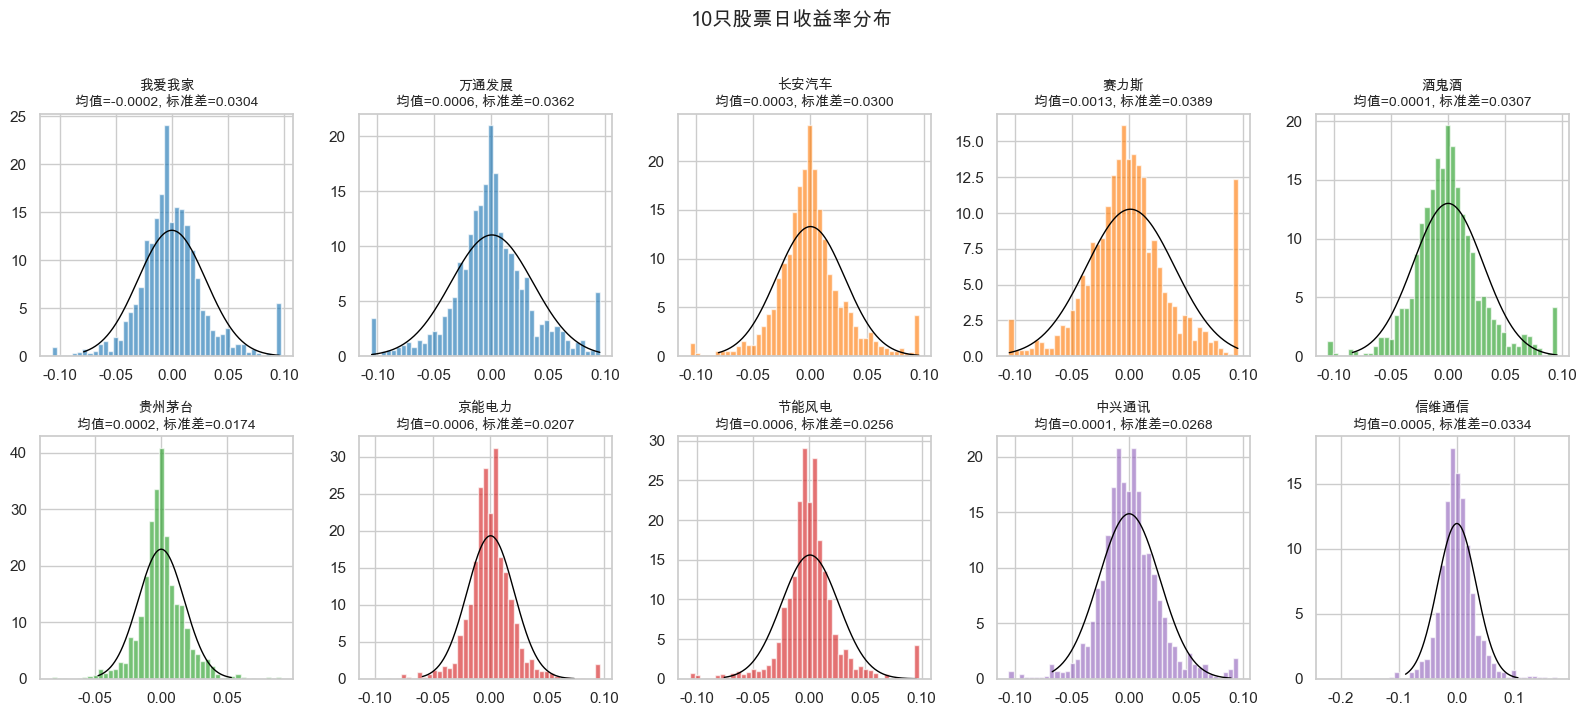

In [5]:

ordered = stock_info.sort_values(['industry', 'code'])['code'].tolist()
fig, axes = plt.subplots(2, 5, figsize=(16, 7), sharex=False, sharey=False)
axes = axes.ravel()
for ax, code in zip(axes, ordered):
    g = stock[stock['code'] == code].dropna(subset=['return'])
    r = g['return']
    mu, sd = r.mean(), r.std()
    ax.hist(r, bins=45, density=True, alpha=0.65, color=industry_palette[g['industry'].iloc[0]])
    xs = np.linspace(r.quantile(0.01), r.quantile(0.99), 200)
    ax.plot(xs, stats.norm.pdf(xs, mu, sd), color='black', linewidth=1)
    ax.set_title(f"{g['name'].iloc[0]}\n均值={mu:.4f}, 标准差={sd:.4f}", fontsize=10)
fig.suptitle('10只股票日收益率分布', y=1.02)
fig.tight_layout()
fig.savefig(PROJECT_ROOT / 'output/fig02_return_distribution.png', dpi=180, bbox_inches='tight')
plt.show()


图 2 显示，多数股票的日收益率集中在 0 附近，但尾部通常比正态分布更厚，极端涨跌并不少见。标准差越大，短期价格波动越强；周期性或成长属性更强的股票通常更明显。


### 图 3：收益率相关系数热力图

按行业排序后计算日收益率相关系数，用来观察同行业股票和跨行业股票之间的联动差异。


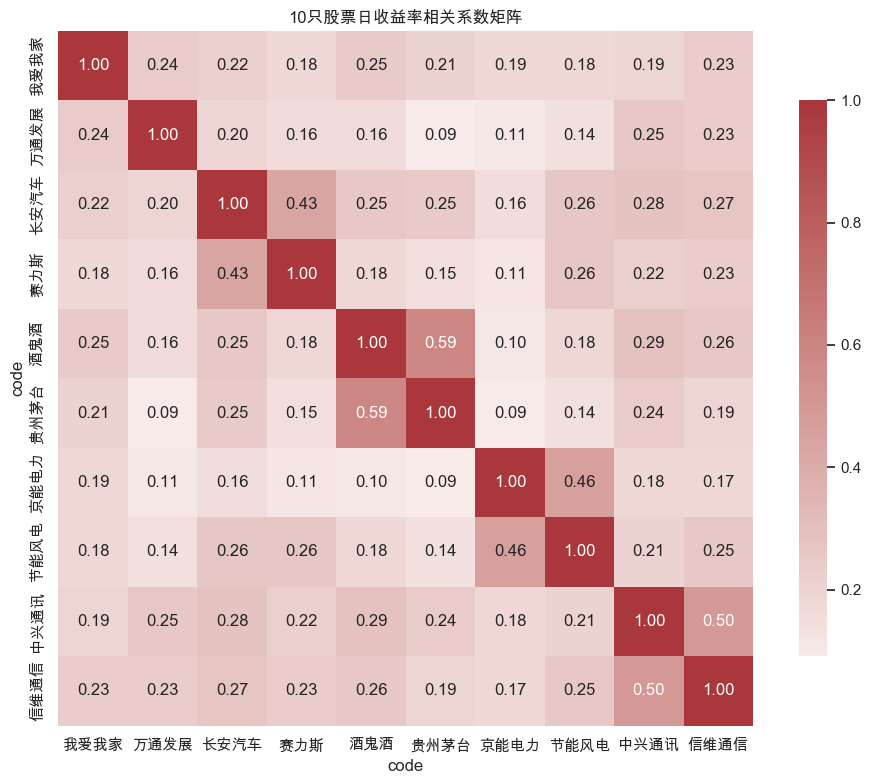

In [6]:

ret_wide = stock.pivot(index='date', columns='code', values='return')[ordered]
label_map = stock_info.set_index('code')['name'].to_dict()
corr = ret_wide.corr()
corr_labels = corr.rename(index=label_map, columns=label_map)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_labels, annot=True, fmt='.2f', cmap='vlag', center=0, square=True, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('10只股票日收益率相关系数矩阵')
fig.tight_layout()
fig.savefig(PROJECT_ROOT / 'output/fig03_return_corr_heatmap.png', dpi=180)
plt.show()


图 3 用来判断行业因素是否带来更强的收益联动。如果同行业股票相关系数更高，说明共同的行业冲击比较明显；如果跨行业相关性也不低，则市场整体风险因子的作用可能更强。


### 图 4：宏观指标与股市关系

先把沪深 300 日度收盘价聚合成月度收益率，再和 M2 同比增速做散点图及线性拟合。这里把 M2 同比作为流动性环境的一个近似指标。


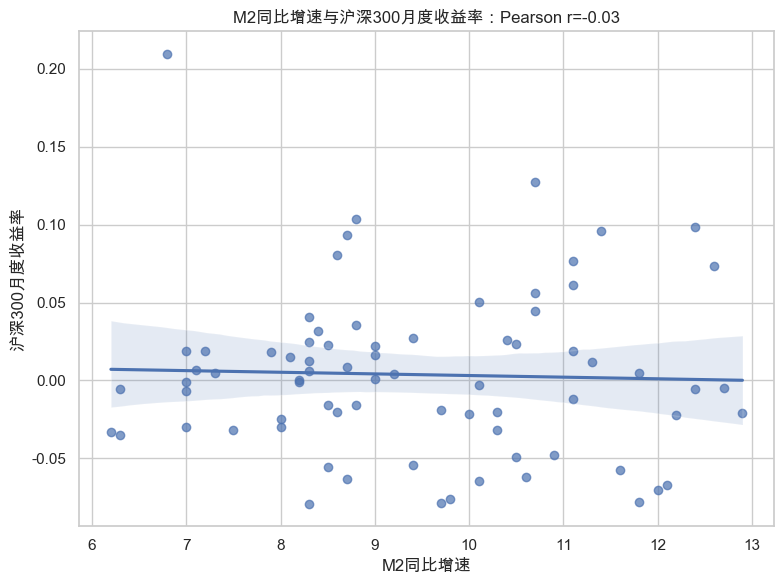

In [7]:

hs300_month = hs300.set_index('date')['close'].resample('M').last().pct_change().rename('hs300_month_return').reset_index()
hs300_month['month'] = hs300_month['date'].dt.to_period('M').astype(str)
macro = combined[['month', 'cpi_yoy', 'm2_yoy']].drop_duplicates('month')
macro_market = hs300_month.merge(macro, on='month', how='left').dropna(subset=['hs300_month_return', 'm2_yoy'])
pearson = macro_market['hs300_month_return'].corr(macro_market['m2_yoy'])

fig, ax = plt.subplots(figsize=(8, 6))
sns.regplot(data=macro_market, x='m2_yoy', y='hs300_month_return', ax=ax, scatter_kws={'alpha': 0.7})
ax.set_title(f'M2同比增速与沪深300月度收益率：Pearson r={pearson:.2f}')
ax.set_xlabel('M2同比增速')
ax.set_ylabel('沪深300月度收益率')
fig.tight_layout()
fig.savefig(PROJECT_ROOT / 'output/fig04_macro_m2_hs300.png', dpi=180)
plt.show()


图 4 的相关系数只说明 M2 同比增速和沪深 300 月度收益率在样本中的线性关系。M2 增速较高时，市场流动性往往更宽松，但散点图不能证明因果关系；盈利预期、政策变化和海外市场也会同时影响股票收益。


### 图 5（选做）：财务指标跨公司对比

这里画最近 5 年 ROE 折线图，用来比较不同公司的盈利能力变化。


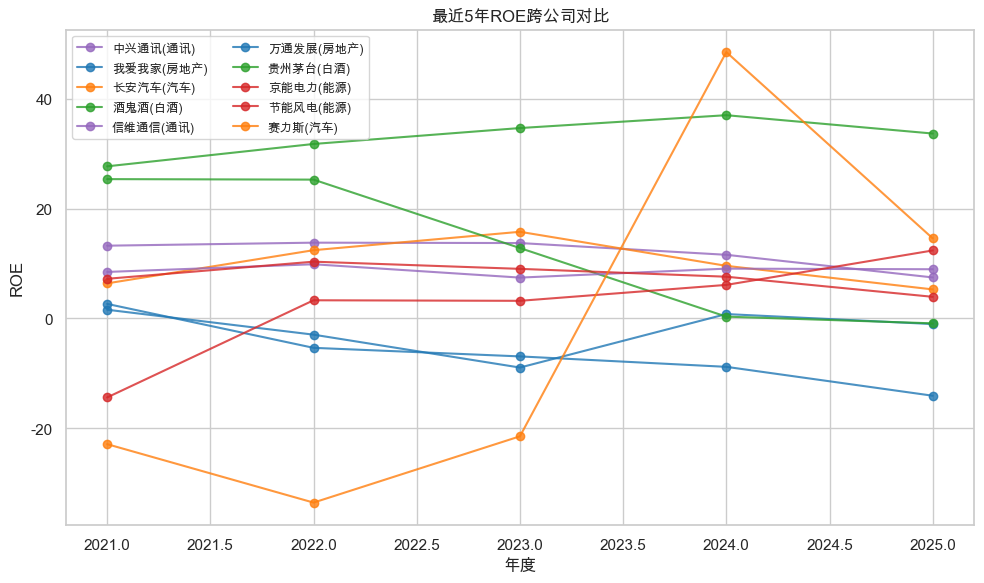

In [8]:

if 'roe' in finance.columns:
    fig, ax = plt.subplots(figsize=(10, 6))
    for (code, name, industry), g in finance.dropna(subset=['roe']).groupby(['code', 'name', 'industry']):
        ax.plot(g['year'], g['roe'], marker='o', label=f'{name}({industry})', color=industry_palette[industry], alpha=0.8)
    ax.set_title('最近5年ROE跨公司对比')
    ax.set_xlabel('年度')
    ax.set_ylabel('ROE')
    ax.legend(ncol=2, fontsize=9)
    fig.tight_layout()
    fig.savefig(PROJECT_ROOT / 'output/fig05_finance_roe.png', dpi=180)
    plt.show()
else:
    print('finance_wide.csv 中没有 roe 列，跳过图 5。')


ROE 折线图主要看盈利能力的水平和稳定性。白酒龙头通常 ROE 较高；地产和能源行业更容易受到周期和政策变化影响。


# 第五部分：回归分析

## 5.1 CAPM 模型估计

无风险利率设为年化 2%，换算成日频后为 `0.02 / 252`。然后对 10 只股票分别估计 CAPM，并汇总 Alpha、Beta、置信区间和 R²。


In [9]:

rf_daily = 0.02 / 252
capm_rows = []
for code, g in combined.dropna(subset=['return', 'hs300_return']).groupby('code'):
    g = g.sort_values('date')
    y = g['return'] - rf_daily
    x = g['hs300_return'] - rf_daily
    X = sm.add_constant(x)
    model = sm.OLS(y, X, missing='drop').fit()
    info = g[['name', 'industry']].iloc[0]
    ci = model.conf_int().loc['hs300_return']
    capm_rows.append({
        '股票': info['name'], '代码': code, '行业': info['industry'],
        'alpha': model.params['const'], 'alpha_pvalue': model.pvalues['const'],
        'beta': model.params['hs300_return'],
        'beta_ci_low': ci[0], 'beta_ci_high': ci[1],
        'r_squared': model.rsquared
    })
capm = pd.DataFrame(capm_rows).sort_values(['行业', '代码'])
capm.to_csv(PROJECT_ROOT / 'output/capm_results.csv', index=False, encoding='utf-8-sig')
capm


,股票,代码,行业,alpha,alpha_pvalue,beta,beta_ci_low,beta_ci_high,r_squared
1,我爱我家,000560,房地产,-0.000323,0.653849,0.941908,0.822542,1.061274,0.134850
5,万通发展,600246,房地产,0.000474,0.593095,0.837224,0.690462,0.983986,0.075372
2,长安汽车,000625,汽车,0.000213,0.752486,1.191219,1.079423,1.303014,0.221312
9,赛力斯,601127,汽车,0.001178,0.205487,1.130858,0.976757,1.284958,0.118861
3,酒鬼酒,000799,白酒,0.000022,0.973360,1.455663,1.348608,1.562719,0.316387
6,贵州茅台,600519,白酒,0.000099,0.766999,0.964329,0.908973,1.019685,0.431714
7,京能电力,600578,能源,0.000544,0.277443,0.541774,0.458915,0.624633,0.096673
8,节能风电,601016,能源,0.000531,0.375956,0.853046,0.753907,0.952186,0.156874
0,中兴通讯,000063,通讯,-0.000040,0.943441,1.247095,1.152636,1.341554,0.303922
4,信维通信,300136,通讯,0.000394,0.595779,1.379270,1.256302,1.502237,0.239508


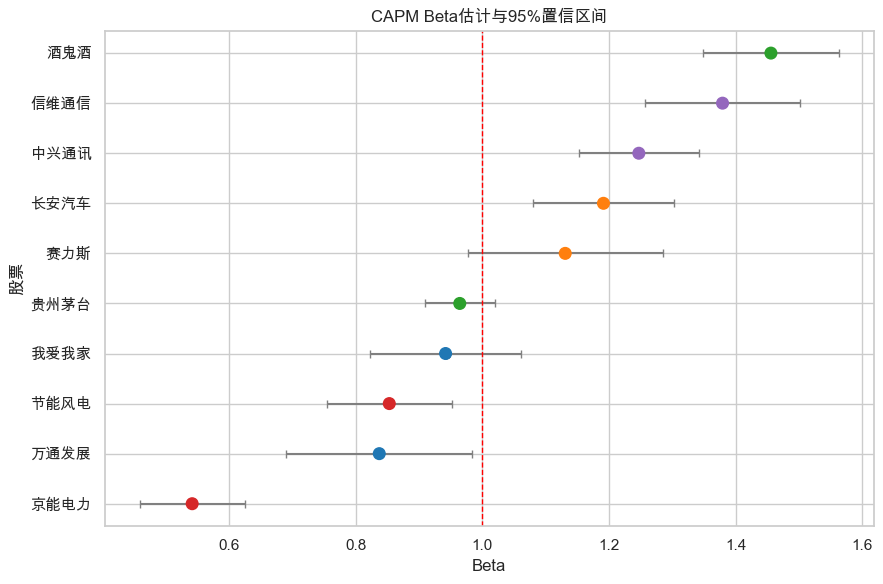

In [10]:

capm_plot = capm.sort_values('beta')
fig, ax = plt.subplots(figsize=(9, 6))
colors = [industry_palette[ind] for ind in capm_plot['行业']]
xerr = np.vstack([capm_plot['beta'] - capm_plot['beta_ci_low'], capm_plot['beta_ci_high'] - capm_plot['beta']])
ax.errorbar(capm_plot['beta'], capm_plot['股票'], xerr=xerr, fmt='o', ecolor='gray', color='black', capsize=3)
ax.scatter(capm_plot['beta'], capm_plot['股票'], c=colors, s=70, zorder=3)
ax.axvline(1, color='red', linestyle='--', linewidth=1)
ax.set_title('CAPM Beta估计与95%置信区间')
ax.set_xlabel('Beta')
ax.set_ylabel('股票')
fig.tight_layout()
fig.savefig(PROJECT_ROOT / 'output/fig06_capm_beta.png', dpi=180)
plt.show()


Beta 系数点图用来比较每只股票相对沪深 300 的市场敏感度。误差棒给出 95% 置信区间，红色竖线 `beta=1` 是区分高于或低于市场波动敏感度的参考线。


In [11]:

beta_gt_1 = capm[capm['beta'] > 1][['股票', '行业', 'beta']]
alpha_sig = capm[capm['alpha_pvalue'] < 0.05][['股票', '行业', 'alpha', 'alpha_pvalue']]
r2_high = capm.loc[capm['r_squared'].idxmax(), ['股票', '行业', 'r_squared']]
r2_low = capm.loc[capm['r_squared'].idxmin(), ['股票', '行业', 'r_squared']]
print('Beta > 1 的股票：')
display(beta_gt_1)
print('Alpha 在 5% 水平显著的股票：')
display(alpha_sig)
print('R2 最高：')
display(r2_high.to_frame().T)
print('R2 最低：')
display(r2_low.to_frame().T)


Beta > 1 的股票：


,股票,行业,beta
2,长安汽车,汽车,1.191219
9,赛力斯,汽车,1.130858
3,酒鬼酒,白酒,1.455663
0,中兴通讯,通讯,1.247095
4,信维通信,通讯,1.379270


Alpha 在 5% 水平显著的股票：


,股票,行业,alpha,alpha_pvalue


R2 最高：


,股票,行业,r_squared
6,贵州茅台,白酒,0.431714


R2 最低：


,股票,行业,r_squared
5,万通发展,房地产,0.075372


CAPM 结果需要回答三个问题：

1. `beta > 1` 的股票包括长安汽车、赛力斯、酒鬼酒、中兴通讯和信维通信，主要来自汽车、白酒和通讯行业。其中汽车和通讯样本对市场波动更敏感，和成长性、产业周期较强的行业特征基本一致；酒鬼酒的 Beta 也较高，说明它在样本期内并不像防御型消费龙头那样稳定。
2. 本次样本中没有股票的 Alpha 在 5% 水平显著异于 0。这说明在 CAPM 控制沪深 300 市场风险后，样本内没有找到稳定的异常收益证据；如果 Alpha 显著，也需要进一步判断是否来自遗漏的行业因子、风格因子或公司事件。
3. R² 最高的是贵州茅台，说明它的日收益在本样本中相对更容易被沪深 300 解释；R² 最低的是万通发展，说明该股票收益中个股或行业特有因素占比更高。地产样本更容易受到政策、融资环境和公司事件影响，所以单一市场因子解释力偏低并不意外。


# 第六部分：分析报告

## 6.1 结论

本项目完成了作业要求的完整流程：公开数据下载、CSV/Parquet 存储、单表清洗、宽表与长表转换、多表合并、描述统计、图形分析和 CAPM 回归。结果显示，行业属性会影响收益相关性、波动率和 Beta 暴露；宏观指标和市场收益之间存在样本相关性，但不能只凭散点图解释为因果关系。

从作业角度看，CSV 是主分析数据源，Parquet 用于展示列式存储和类型保留的优势。清洗后的 `combined_data.csv` 把股票收益、沪深 300 收益和月度宏观变量放在同一张表中，后续可以继续扩展到更多因子模型或宏观敏感性分析。
